# Práctica 4. Puertas cuánticas de un qubit con Qiskit

## Información general

**Asignatura:** Computación cuántica  
**Sesión:** 5  
**Título:** Puertas cuánticas de un qubit   
**Modalidad:** Individual  
**Entorno recomendado:** Jupyter Notebook  
**Bibliotecas:** NumPy, Matplotlib, Qiskit y Qiskit Aer

## Objetivos

En esta práctica vas a trabajar con puertas cuánticas de un qubit desde dos puntos de vista:

- Como matrices aplicadas a vectores de estado.
- Como operaciones dentro de circuitos de Qiskit.

Al finalizar la práctica deberás ser capaz de:

- Definir puertas cuánticas como matrices unitarias.
- Aplicar puertas a estados de un qubit usando NumPy.
- Reproducir las mismas operaciones con Qiskit.
- Obtener el vector de estado resultante con `Statevector`.
- Calcular probabilidades de medida.
- Distinguir puertas que modifican probabilidades de puertas que modifican fase.
- Analizar el efecto del orden de aplicación de las puertas.
- Simular medidas y comparar probabilidades teóricas con conteos experimentales.

## Entrega

Entrega este notebook completado con:

- Código ejecutado.
- Resultados visibles.
- Tablas completadas cuando se soliciten.
- Gráficas generadas.
- Respuestas razonadas en las celdas indicadas.
- Conclusión final.

## 1. Preparación del entorno

Ejecuta la siguiente celda para importar las bibliotecas necesarias.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

def applyStyle():
    plt.style.use("default")

    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif", "serif"]
    plt.rcParams["font.size"] = 12
    plt.rcParams["axes.labelsize"] = 12
    plt.rcParams["axes.titlesize"] = 12
    plt.rcParams["xtick.labelsize"] = 10
    plt.rcParams["ytick.labelsize"] = 10
    plt.rcParams["legend.fontsize"] = 10

    plt.rcParams["xtick.direction"] = "in"
    plt.rcParams["ytick.direction"] = "in"
    plt.rcParams["xtick.top"] = True
    plt.rcParams["ytick.right"] = True
    plt.rcParams["xtick.minor.visible"] = True
    plt.rcParams["ytick.minor.visible"] = True

    plt.rcParams["lines.linewidth"] = 1.0
    plt.rcParams["lines.markersize"] = 3

    plt.rcParams["legend.frameon"] = True
    plt.rcParams["legend.edgecolor"] = "black"
    plt.rcParams["legend.fancybox"] = False

COLOR_TARGET = "#5d54a4"  # Blue violet
COLOR_PRED = "#9154a4"    # Purple
COLOR_ERR = "#404040"     # Dark gray

SEED = 42
np.set_printoptions(precision=5, suppress=True)

applyStyle()


def probsDict(state, decimals=5):
    # probabilities_dict() with plain str/float values, easier to read
    return {str(k): round(float(v), decimals) for k, v in state.probabilities_dict().items()}

## 2. Parte A. Puertas como matrices

### Ejercicio 1. Estados de la base computacional

Define con NumPy los estados:

$$
|0\rangle =
\begin{pmatrix}
1 \\
0
\end{pmatrix}
$$

$$
|1\rangle =
\begin{pmatrix}
0 \\
1
\end{pmatrix}
$$

Utiliza explícitamente `dtype=complex`.

In [2]:
ket0 = np.array([1, 0], dtype=complex)
ket1 = np.array([0, 1], dtype=complex)

for name, ket in [("|0>", ket0), ("|1>", ket1)]:
    print(name)
    print(f"  vector = {ket}")
    print(f"  dtype  = {ket.dtype}")
    print(f"  norm   = {np.linalg.norm(ket):.5f}")
    print()

|0>
  vector = [1.+0.j 0.+0.j]
  dtype  = complex128
  norm   = 1.00000

|1>
  vector = [0.+0.j 1.+0.j]
  dtype  = complex128
  norm   = 1.00000



**Responde:**

1. ¿Qué representa cada componente del vector?
2. ¿Por qué la norma debe ser 1?
3. ¿Por qué usamos `dtype=complex`?

**Respuesta:**

1. Cada componente es la amplitud de un estado de la base: la primera es la de |0⟩ y la segunda la de |1⟩. Su módulo al cuadrado es la probabilidad de medir ese resultado. En `ket0` la amplitud de |0⟩ es 1 y la de |1⟩ es 0.

2. Porque |α|² + |β|² son las probabilidades de todos los resultados posibles y tienen que sumar 1. Los dos estados salen con `norm = 1.00000`.

3. Porque en general las amplitudes son complejas y ahí va la fase. Aunque |0⟩ y |1⟩ solo tengan 1 y 0, al aplicar puertas como Y o S aparecen amplitudes imaginarias (Y|0⟩ = i|1⟩ en el ejercicio 5). Con arrays reales se perderían.

### Ejercicio 2. Definición de puertas básicas

Define con NumPy las matrices de las siguientes puertas:

$$
I =
\begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}
$$

$$
X =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
$$

$$
Y =
\begin{pmatrix}
0 & -i \\
i & 0
\end{pmatrix}
$$

$$
Z =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
$$

$$
H =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
$$

In [3]:
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

basicGates = {"I": I, "X": X, "Y": Y, "Z": Z, "H": H}

for name, gate in basicGates.items():
    print(f"{name} (shape {gate.shape}) =")
    print(gate)
    print()

I (shape (2, 2)) =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

X (shape (2, 2)) =
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Y (shape (2, 2)) =
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Z (shape (2, 2)) =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

H (shape (2, 2)) =
[[ 0.70711+0.j  0.70711+0.j]
 [ 0.70711+0.j -0.70711+0.j]]



**Responde:**

1. ¿Qué dimensión tiene cada matriz?
2. ¿Por qué una puerta de un qubit se representa con una matriz 2 x 2?
3. ¿Qué diferencia observas entre las puertas X, Y y Z?

**Respuesta:**

1. Todas son 2 × 2, como sale en la salida (`shape (2, 2)`).

2. Porque el estado de un qubit es un vector de 2 amplitudes, y una puerta tiene que transformar un vector de ℂ² en otro de ℂ². Eso es una matriz 2 × 2.

3. X intercambia las dos amplitudes (es el NOT). Z no las intercambia, solo cambia el signo de la amplitud de |1⟩. Y hace las dos cosas a la vez, intercambia y además mete una fase ±i. Por eso X e Y cambian las probabilidades al actuar sobre |0⟩ y Z no.

### Ejercicio 3. Comprobación de unitariedad

Implementa una función que compruebe si una matriz es unitaria:

$$
U^\dagger U = I
$$

Recuerda que $U^\dagger$ es la traspuesta conjugada de U.

In [4]:
def isUnitary(U, tolerance=1e-10):
    U = np.asarray(U, dtype=complex)

    if U.ndim != 2 or U.shape[0] != U.shape[1]:  # is it a square matrix?
        return False

    identity = np.eye(U.shape[0], dtype=complex)

    return bool(np.allclose(U.conj().T @ U, identity, atol=tolerance))  # U†U = I?

In [5]:
for name, gate in basicGates.items():
    print(f"{name:3s} -> {isUnitary(gate)}")

print()

cases = {
    "notSquare": (np.ones((2, 3)), "2x3, not square"),
    "scaledX": (2 * X, "U†U = 4I != I"),
    "projector": (np.array([[1, 0], [0, 0]]), "|0><0| loses information, not reversible"),
}

for name, (matrix, justification) in cases.items():
    print(f"{name:12s} -> {str(isUnitary(matrix)):5s} | {justification}")

I   -> True
X   -> True
Y   -> True
Z   -> True
H   -> True

notSquare    -> False | 2x3, not square
scaledX      -> False | U†U = 4I != I
projector    -> False | |0><0| loses information, not reversible


Completa la tabla:

| Puerta | ¿Es unitaria? |
|---|---:|
| I | Sí |
| X | Sí |
| Y | Sí |
| Z | Sí |
| H | Sí |

**Responde:**

1. ¿Son unitarias todas las puertas anteriores?
2. ¿Qué propiedad del estado garantiza la unitariedad?
3. ¿Por qué una puerta cuántica debe ser reversible?

**Respuesta:**

1. Sí, las cinco salen `True`. En cambio los casos de prueba (una matriz 2x3, 2X y el proyector |0⟩⟨0|) salen `False`, así que la función sí detecta cuando no lo es.

2. La normalización. Una matriz unitaria conserva la norma, así que si el estado entra con norma 1 sale con norma 1 y las probabilidades siguen sumando 1.

3. Porque la evolución de un sistema cuántico cerrado es unitaria, y toda matriz unitaria tiene inversa, U⁻¹ = U†. Si una operación perdiera información (como el proyector de la tabla de pruebas) no se podría deshacer y no sería una puerta cuántica, sería algo como una medida.

## 3. Parte B. Aplicación de puertas con NumPy

### Ejercicio 4. Función para calcular probabilidades

Implementa una función que devuelva las probabilidades de medir 0 y 1 en la base computacional.

In [6]:
def computeProbabilities(state):
    state = np.asarray(state, dtype=complex)

    probs = np.abs(state) ** 2  # Born rule: |amplitude|²

    return {0: float(probs[0]), 1: float(probs[1])}

### Ejercicio 5. Aplicar puertas a $|0\rangle$

Aplica las puertas I, X, Y, Z y H al estado $|0\rangle$.

In [7]:
resultsKet0 = {}

print(f"{'gate':>4} | {'state':<26} | {'P(0)':>5} {'P(1)':>5}")
print("-" * 48)

for name, gate in basicGates.items():
    finalState = gate @ ket0
    resultsKet0[name] = finalState
    p = computeProbabilities(finalState)
    print(f"{name:>4} | {str(finalState):<26} | {p[0]:>5.2f} {p[1]:>5.2f}")

gate | state                      |  P(0)  P(1)
------------------------------------------------
   I | [1.+0.j 0.+0.j]            |  1.00  0.00
   X | [0.+0.j 1.+0.j]            |  0.00  1.00
   Y | [0.+0.j 0.+1.j]            |  0.00  1.00
   Z | [1.+0.j 0.+0.j]            |  1.00  0.00
   H | [0.70711+0.j 0.70711+0.j]  |  0.50  0.50


Completa la tabla:

| Puerta | Estado resultante | Probabilidad de 0 | Probabilidad de 1 |
|---|---|---:|---:|
| I | \|0⟩ = (1, 0) | 1 | 0 |
| X | \|1⟩ = (0, 1) | 0 | 1 |
| Y | i\|1⟩ = (0, i) | 0 | 1 |
| Z | \|0⟩ = (1, 0) | 1 | 0 |
| H | \|+⟩ = (1/√2, 1/√2) | 0.5 | 0.5 |

**Responde:**

1. ¿Qué puertas cambian las probabilidades al aplicarse sobre $|0\rangle$?
2. ¿Qué puertas no cambian las probabilidades?
3. ¿Qué diferencia hay entre $X|0\rangle$ e $Y|0\rangle$?
4. ¿Se puede distinguir esa diferencia midiendo directamente en la base computacional?

**Respuesta:**

1. X e Y, que pasan de P(0) = 1 a P(1) = 1, y H, que deja 0.5 y 0.5.

2. I y Z. I no hace nada y Z sobre |0⟩ tampoco, porque solo cambia el signo de la amplitud de |1⟩, que aquí es 0.

3. X|0⟩ = |1⟩ e Y|0⟩ = i|1⟩. Se diferencian solo en un factor i, que es una fase global.

4. No. Los dos dan P(1) = 1, porque |i|² = 1. Y como es una fase global, no se puede distinguir con ninguna medida, son físicamente el mismo estado.

### Ejercicio 6. Aplicar puertas a $|1\rangle$

Repite el ejercicio anterior aplicando las mismas puertas a $|1\rangle$.

In [8]:
resultsKet1 = {}

print(f"{'gate':>4} | {'state':<26} | {'P(0)':>5} {'P(1)':>5}")
print("-" * 48)

for name, gate in basicGates.items():
    finalState = gate @ ket1
    resultsKet1[name] = finalState
    p = computeProbabilities(finalState)
    print(f"{name:>4} | {str(finalState):<26} | {p[0]:>5.2f} {p[1]:>5.2f}")

print()
print(f"Z|1> equals -|1>? {np.allclose(Z @ ket1, -ket1)}")

gate | state                      |  P(0)  P(1)
------------------------------------------------
   I | [0.+0.j 1.+0.j]            |  0.00  1.00
   X | [1.+0.j 0.+0.j]            |  1.00  0.00
   Y | [0.-1.j 0.+0.j]            |  1.00  0.00
   Z | [ 0.+0.j -1.+0.j]          |  0.00  1.00
   H | [ 0.70711+0.j -0.70711+0.j] |  0.50  0.50

Z|1> equals -|1>? True


Completa la tabla:

| Puerta | Estado resultante | Probabilidad de 0 | Probabilidad de 1 |
|---|---|---:|---:|
| I | \|1⟩ = (0, 1) | 0 | 1 |
| X | \|0⟩ = (1, 0) | 1 | 0 |
| Y | −i\|0⟩ = (−i, 0) | 1 | 0 |
| Z | −\|1⟩ = (0, −1) | 0 | 1 |
| H | \|−⟩ = (1/√2, −1/√2) | 0.5 | 0.5 |

**Responde:**

1. ¿Qué resultado produce $X|1\rangle$?
2. ¿Qué resultado produce $Z|1\rangle$?
3. ¿Son físicamente distinguibles $|1\rangle$ y $-|1\rangle$ mediante una medida directa?
4. ¿Qué estado produce $H|1\rangle$?

**Respuesta:**

1. |0⟩. X intercambia las amplitudes y vuelve a |0⟩.

2. −|1⟩. Z cambia el signo de la amplitud de |1⟩, se ve en la salida `Z|1> equals -|1>? True`.

3. No. El −1 multiplica a todo el estado, así que es una fase global. Los dos dan P(1) = 1 y en realidad son el mismo estado físico, no se distinguen con ninguna medida.

4. |−⟩ = (|0⟩ − |1⟩)/√2. Tiene 0.5 y 0.5 como H|0⟩, pero con el signo menos en |1⟩.

### Ejercicio 7. Estados $|+\rangle$ y $|-\rangle$

Define los estados:

$$
|+\rangle =
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

$$
|-\rangle =
\frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$

In [9]:
ketPlus = (ket0 + ket1) / np.sqrt(2)
ketMinus = (ket0 - ket1) / np.sqrt(2)

for name, ket in [("|+>", ketPlus), ("|->", ketMinus)]:
    p = computeProbabilities(ket)
    print(name)
    print(f"  vector = {ket}")
    print(f"  norm   = {np.linalg.norm(ket):.5f}")
    print(f"  P(0) = {p[0]:.3f}, P(1) = {p[1]:.3f}")
    print()

print(f"|+> equals |->?  {np.allclose(ketPlus, ketMinus)}")
print(f"H|0> equals |+>? {np.allclose(H @ ket0, ketPlus)}")
print(f"H|1> equals |->? {np.allclose(H @ ket1, ketMinus)}")

|+>
  vector = [0.70711+0.j 0.70711+0.j]
  norm   = 1.00000
  P(0) = 0.500, P(1) = 0.500

|->
  vector = [ 0.70711+0.j -0.70711+0.j]
  norm   = 1.00000
  P(0) = 0.500, P(1) = 0.500

|+> equals |->?  False
H|0> equals |+>? True
H|1> equals |->? True


**Responde:**

1. ¿Tienen las mismas probabilidades en la base computacional?
2. ¿Son el mismo estado?
3. ¿Qué diferencia hay entre ellos?
4. ¿Qué concepto aparece aquí?

**Respuesta:**

1. Sí, los dos dan P(0) = P(1) = 0.5.

2. No. En la salida `|+> equals |->? False`.

3. El signo de la amplitud de |1⟩: +1/√2 en |+⟩ y −1/√2 en |−⟩. Como el signo solo afecta a una componente, no es una fase global.

4. La fase relativa. Dos estados con las mismas probabilidades pueden ser distintos por la fase relativa entre sus amplitudes, y esa diferencia no se ve midiendo directamente en la base computacional.

## 4. Parte C. Las mismas puertas con Qiskit

### Ejercicio 8. Puerta X en Qiskit

Crea un circuito de un qubit que aplique una puerta X, dibújalo y obtén su vector de estado.

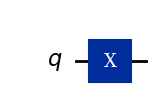

<IPython.core.display.Latex object>

vector        = [0.+0.j 1.+0.j]
probabilities = {'1': 1.0}
equal to X @ ket0 (NumPy)? True


In [10]:
qc = QuantumCircuit(1)
qc.x(0)

display(qc.draw("mpl"))

state = Statevector.from_instruction(qc)
display(state.draw("latex"))

print(f"vector        = {state.data}")
print(f"probabilities = {probsDict(state)}")
print(f"equal to X @ ket0 (NumPy)? {np.allclose(state.data, X @ ket0)}")

**Responde:**

1. ¿Cuál es el estado inicial por defecto en Qiskit?
2. ¿Qué estado se obtiene después de aplicar \(X\)?
3. ¿Coincide con el cálculo hecho con NumPy?

**Respuesta:**

1. |0⟩. Qiskit inicializa todos los qubits en |0⟩.

2. |1⟩, con vector (0, 1) y `probabilities = {'1': 1.0}`.

3. Sí, sale `equal to X @ ket0 (NumPy)? True`.

### Ejercicio 9. Función auxiliar para analizar circuitos

Completa la función `analizar_circuito`.

In [11]:
def analyzeCircuit(qc):
    state = Statevector.from_instruction(qc)

    display(qc.draw("mpl"))
    display(state.draw("latex"))

    probs = probsDict(state)
    print(f"probabilities = {probs}")

    return state, probs

### Ejercicio 10. Puertas I, X, Y, Z y H en Qiskit

Crea un circuito independiente para cada una de las puertas:

- `id`
- `x`
- `y`
- `z`
- `h`

Todas deben aplicarse sobre el estado inicial $|0\rangle$.

Gate I:


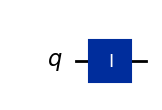

<IPython.core.display.Latex object>

probabilities = {'0': 1.0}
  vector          = [1.+0.j 0.+0.j]
  equal to NumPy? True

Gate X:


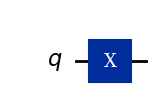

<IPython.core.display.Latex object>

probabilities = {'1': 1.0}
  vector          = [0.+0.j 1.+0.j]
  equal to NumPy? True

Gate Y:


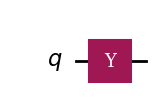

<IPython.core.display.Latex object>

probabilities = {'1': 1.0}
  vector          = [0.+0.j 0.+1.j]
  equal to NumPy? True

Gate Z:


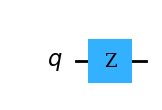

<IPython.core.display.Latex object>

probabilities = {'0': 1.0}
  vector          = [1.+0.j 0.+0.j]
  equal to NumPy? True

Gate H:


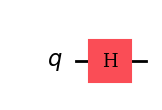

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}
  vector          = [0.70711+0.j 0.70711+0.j]
  equal to NumPy? True



In [12]:
qiskitCircuits = {}
gateMethods = {"I": "id", "X": "x", "Y": "y", "Z": "z", "H": "h"}

for label, method in gateMethods.items():
    qc = QuantumCircuit(1)
    getattr(qc, method)(0)  # e.g. qc.x(0)
    qiskitCircuits[label] = qc

for name, circuit in qiskitCircuits.items():
    print(f"Gate {name}:")
    state, probs = analyzeCircuit(circuit)
    print(f"  vector          = {state.data}")
    print(f"  equal to NumPy? {np.allclose(state.data, resultsKet0[name])}")
    print()

**Responde:**

1. ¿Qué puertas producen cambios visibles en las probabilidades?
2. ¿Qué puertas producen cambios de fase?
3. ¿Qué información muestra `Statevector` que no aparece en un histograma?

**Respuesta:**

1. X, Y y H. X e Y llevan todo a 1 y H deja 0.5 y 0.5. I y Z dejan `{'0': 1.0}`.

2. Y, que da i|1⟩ (se ve en el `Statevector`), y Z, aunque sobre |0⟩ no se nota porque la amplitud de |1⟩ es 0. La fase de Z aparece cuando hay superposición, como en el ejercicio 13. En todos los casos coincide con NumPy (`equal to NumPy? True`).

3. Las amplitudes completas, con su fase. Por ejemplo X|0⟩ = |1⟩ e Y|0⟩ = i|1⟩ darían el mismo histograma, pero el `Statevector` muestra el factor i.

## 5. Parte D. Puertas de fase

### Ejercicio 11. Puertas S y T con NumPy

Define con NumPy las puertas:

$$
S =
\begin{pmatrix}
1 & 0 \\
0 & i
\end{pmatrix}
$$

$$
T =
\begin{pmatrix}
1 & 0 \\
0 & e^{i\pi/4}
\end{pmatrix}
$$

In [13]:
S = np.array([[1, 0], [0, 1j]], dtype=complex)
T = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex)

print("S =")
print(S)
print()
print("T =")
print(T)
print()

print(f"S unitary: {isUnitary(S)}")
print(f"T unitary: {isUnitary(T)}")
print(f"T² == S:   {np.allclose(T @ T, S)}")

S =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]

T =
[[1.     +0.j      0.     +0.j     ]
 [0.     +0.j      0.70711+0.70711j]]

S unitary: True
T unitary: True
T² == S:   True


In [14]:
phaseInputStates = {"|0>": ket0, "|1>": ket1, "|+>": ketPlus}
phaseGates = {"S": S, "T": T}
phaseResults = {}

print(f"{'gate':>4} | {'input':>5} | {'final state':<36} | {'P(0)':>5} {'P(1)':>5}")
print("-" * 66)

for gateName, gate in phaseGates.items():
    for stateName, initialState in phaseInputStates.items():
        finalState = gate @ initialState
        phaseResults[(gateName, stateName)] = finalState
        p = computeProbabilities(finalState)
        print(f"{gateName:>4} | {stateName:>5} | {str(finalState):<36} | {p[0]:>5.2f} {p[1]:>5.2f}")

gate | input | final state                          |  P(0)  P(1)
------------------------------------------------------------------
   S |   |0> | [1.+0.j 0.+0.j]                      |  1.00  0.00
   S |   |1> | [0.+0.j 0.+1.j]                      |  0.00  1.00
   S |   |+> | [0.70711+0.j      0.     +0.70711j]  |  0.50  0.50
   T |   |0> | [1.+0.j 0.+0.j]                      |  1.00  0.00
   T |   |1> | [0.     +0.j      0.70711+0.70711j]  |  0.00  1.00
   T |   |+> | [0.70711+0.j  0.5    +0.5j]          |  0.50  0.50


Completa la tabla:

| Puerta | Estado inicial | Estado final | Probabilidades |
|---|---|---|---|
| S | $\|0\rangle$ | \|0⟩ = (1, 0) | P(0) = 1, P(1) = 0 |
| S | $\|1\rangle$ | i\|1⟩ = (0, i) | P(0) = 0, P(1) = 1 |
| S | $\|+\rangle$ | (\|0⟩ + i\|1⟩)/√2 | P(0) = 0.5, P(1) = 0.5 |
| T | $\|0\rangle$ | \|0⟩ = (1, 0) | P(0) = 1, P(1) = 0 |
| T | $\|1\rangle$ | e^(iπ/4)\|1⟩ = (0, 0.707 + 0.707i) | P(0) = 0, P(1) = 1 |
| T | $\|+\rangle$ | (\|0⟩ + e^(iπ/4)\|1⟩)/√2 = (0.707, 0.5 + 0.5i) | P(0) = 0.5, P(1) = 0.5 |

**Responde:**

1. ¿Cambian las probabilidades al aplicar S o T sobre $|0\rangle$?
2. ¿Cambian las probabilidades al aplicarlas sobre $|1\rangle$?
3. ¿Qué cambia realmente?
4. ¿Por qué es importante la fase relativa?

**Respuesta:**

1. No. |0⟩ se queda igual, porque S y T solo tocan la amplitud de |1⟩, que aquí es 0.

2. No. Siguen dando P(1) = 1, porque |i|² = |e^(iπ/4)|² = 1.

3. La fase de la amplitud de |1⟩: S la multiplica por i (90°) y T por e^(iπ/4) (45°). Sobre |0⟩ o |1⟩ solos es una fase global y no cambia nada físico, pero sobre |+⟩ es una fase relativa y el estado sí cambia, aunque las probabilidades sigan en 0.5 y 0.5.

4. Porque aunque no se vea al medir directamente, cambia cómo interfieren las amplitudes en las puertas siguientes. Con una H después, dos estados con distinta fase relativa dan probabilidades distintas (ejercicio 14).

### Ejercicio 12. Puertas S y T en Qiskit

Reproduce el ejercicio anterior con Qiskit preparando primero $|+\rangle$ y aplicando después `s` o `t`.

Circuit H + S


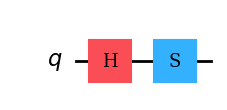

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}
  equal to S|+> (NumPy)? True

Circuit H + T


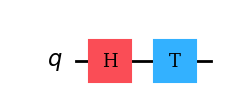

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}
  equal to T|+> (NumPy)? True


In [15]:
qcS = QuantumCircuit(1)
qcS.h(0)  # |+>
qcS.s(0)

qcT = QuantumCircuit(1)
qcT.h(0)  # |+>
qcT.t(0)

print("Circuit H + S")
stateS, probsS = analyzeCircuit(qcS)
print(f"  equal to S|+> (NumPy)? {np.allclose(stateS.data, S @ ketPlus)}")
print()

print("Circuit H + T")
stateT, probsT = analyzeCircuit(qcT)
print(f"  equal to T|+> (NumPy)? {np.allclose(stateT.data, T @ ketPlus)}")

**Responde:**

1. ¿Coinciden los resultados con NumPy?
2. ¿Qué diferencia hay entre `s` y `t`?
3. ¿Puede una puerta cambiar el estado sin cambiar las probabilidades de medida en la base computacional?

**Respuesta:**

1. Sí, salen `equal to S|+> (NumPy)? True` y `equal to T|+> (NumPy)? True`.

2. `s` añade una fase de π/2 a |1⟩ (amplitud √2/2 · i) y `t` una de π/4 (amplitud 1/2 + i/2). T es la mitad de S, de hecho T² = S (`T² == S: True` en el ejercicio 11).

3. Sí. H + S y H + T dan estados distintos a |+⟩, pero las probabilidades siguen siendo 0.5 y 0.5. Solo cambia la fase relativa.

## 6. Parte E. Fase relativa e interferencia

### Ejercicio 13. Comparación entre $|+\rangle$ y $|-\rangle$

Crea dos circuitos.

Circuito A:

```python
qc_a = QuantumCircuit(1)
qc_a.h(0)
```

Circuito B:

```python
qc_b = QuantumCircuit(1)
qc_b.h(0)
qc_b.z(0)
```

Circuit A


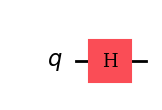

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}
  equal to |+>? True

Circuit B


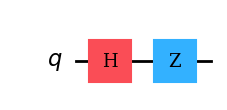

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}
  equal to |->? True

same probabilities? True
same state?         False


In [16]:
qcA = QuantumCircuit(1)
qcA.h(0)

qcB = QuantumCircuit(1)
qcB.h(0)
qcB.z(0)

print("Circuit A")
stateA, probsA = analyzeCircuit(qcA)
print(f"  equal to |+>? {np.allclose(stateA.data, ketPlus)}")
print()

print("Circuit B")
stateB, probsB = analyzeCircuit(qcB)
print(f"  equal to |->? {np.allclose(stateB.data, ketMinus)}")
print()

print(f"same probabilities? {probsA == probsB}")
print(f"same state?         {stateA == stateB}")

**Responde:**

1. ¿Qué estado prepara el circuito A?
2. ¿Qué estado prepara el circuito B?
3. ¿Tienen las mismas probabilidades?
4. ¿Son el mismo estado?
5. ¿Qué diferencia hay entre ellos?

**Respuesta:**

1. |+⟩ = (|0⟩ + |1⟩)/√2 (`equal to |+>? True`).

2. |−⟩ = (|0⟩ − |1⟩)/√2 (`equal to |->? True`).

3. Sí, `same probabilities? True`, las dos 0.5 y 0.5.

4. No, `same state? False`.

5. La fase relativa de |1⟩: + en A y − en B. La Z de B es la que cambia ese signo.

### Ejercicio 14. Convertir fase en probabilidad

Añade una puerta H al final de los dos circuitos anteriores.

Circuito A:

```python
qc_a = QuantumCircuit(1)
qc_a.h(0)
qc_a.h(0)
```

Circuito B:

```python
qc_b = QuantumCircuit(1)
qc_b.h(0)
qc_b.z(0)
qc_b.h(0)
```

Circuit A final


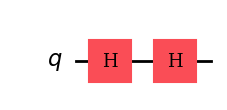

<IPython.core.display.Latex object>

probabilities = {'0': 1.0}

Circuit B final


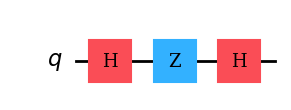

<IPython.core.display.Latex object>

probabilities = {'1': 1.0}


In [17]:
qcAFinal = QuantumCircuit(1)
qcAFinal.h(0)
qcAFinal.h(0)  # final H

qcBFinal = QuantumCircuit(1)
qcBFinal.h(0)
qcBFinal.z(0)
qcBFinal.h(0)  # final H

print("Circuit A final")
stateAFinal, probsAFinal = analyzeCircuit(qcAFinal)
print()

print("Circuit B final")
stateBFinal, probsBFinal = analyzeCircuit(qcBFinal)

Completa la tabla:

| Circuito | Estado antes de la última H | Estado final | P(0) | P(1) |
|---|---|---|---:|---:|
| A | \|+⟩ | \|0⟩ | 1 | 0 |
| B | \|−⟩ | \|1⟩ | 0 | 1 |

**Responde:**

1. ¿Qué resultado produce el circuito A?
2. ¿Qué resultado produce el circuito B?
3. ¿Por qué ahora sí aparece una diferencia en las probabilidades?
4. ¿Qué relación tiene esto con la interferencia cuántica?

**Respuesta:**

1. |0⟩, con `{'0': 1.0}`. Es H·H|0⟩ = |0⟩.

2. |1⟩, con `{'1': 1.0}`.

3. Porque la última H mezcla las dos amplitudes, y el resultado depende del signo relativo. Con |+⟩ las contribuciones a |1⟩ se cancelan y con |−⟩ se cancelan las de |0⟩. La fase, que antes no se veía, se convierte en diferencia de probabilidad.

4. Es justo la interferencia: las amplitudes se suman (constructiva) o se restan (destructiva) según su fase. Es lo que permite aprovechar la fase relativa en los algoritmos cuánticos.

## 7. Parte F. Composición y orden de puertas

### Ejercicio 15. Comparación de órdenes

Crea dos circuitos:

Circuito 1:

```python
qc1 = QuantumCircuit(1)
qc1.h(0)
qc1.z(0)
```

Circuito 2:

```python
qc2 = QuantumCircuit(1)
qc2.z(0)
qc2.h(0)
```

Circuit 1: H then Z


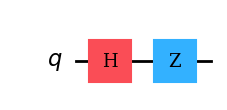

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}

Circuit 2: Z then H


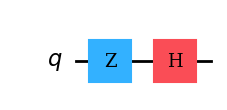

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}

same state?         False
same probabilities? True
state 1 is |->?     True
state 2 is |+>?     True


In [18]:
qc1 = QuantumCircuit(1)
qc1.h(0)
qc1.z(0)

qc2 = QuantumCircuit(1)
qc2.z(0)
qc2.h(0)

print("Circuit 1: H then Z")
state1, probs1 = analyzeCircuit(qc1)
print()

print("Circuit 2: Z then H")
state2, probs2 = analyzeCircuit(qc2)
print()

print(f"same state?         {state1 == state2}")
print(f"same probabilities? {probs1 == probs2}")
print(f"state 1 is |->?     {np.allclose(state1.data, ketMinus)}")
print(f"state 2 is |+>?     {np.allclose(state2.data, ketPlus)}")

**Responde:**

1. ¿Son iguales los estados finales?
2. ¿Son iguales las probabilidades?
3. ¿Por qué puede ocurrir que los estados sean distintos pero las probabilidades iguales?
4. ¿Importa el orden de aplicación de puertas?
5. ¿Qué significa que dos puertas no conmuten?

**Respuesta:**

1. No, `same state? False`. El circuito 1 da |−⟩ y el 2 da |+⟩.

2. Sí, `same probabilities? True`, las dos 0.5 y 0.5.

3. Porque se diferencian solo en la fase relativa (el signo de |1⟩), y la medida en la base computacional solo ve |α|² y |β|².

4. Sí. En el circuito 2 la Z actúa sobre |0⟩ y no hace nada, y en el 1 actúa sobre |+⟩ y lo cambia a |−⟩. Mismas puertas, distinto resultado.

5. Que ZH ≠ HZ, aplicarlas en un orden u otro no da lo mismo. Se comprueba en el ejercicio 16 (`ZH == HZ (commute)? False`).

### Ejercicio 16. Comprobación matricial del orden

Calcula con NumPy:

$$
ZH|0\rangle
$$

y:

$$
HZ|0\rangle
$$

In [19]:
state1Numpy = Z @ H @ ket0  # first H, then Z
state2Numpy = H @ Z @ ket0  # first Z, then H

print(f"ZH|0> = {state1Numpy}")
print(f"HZ|0> = {state2Numpy}")
print()
print(f"ZH|0> equal to circuit 1 (Qiskit)? {np.allclose(state1Numpy, state1.data)}")
print(f"HZ|0> equal to circuit 2 (Qiskit)? {np.allclose(state2Numpy, state2.data)}")
print(f"ZH == HZ (commute)?                {np.allclose(Z @ H, H @ Z)}")

ZH|0> = [ 0.70711+0.j -0.70711+0.j]


HZ|0> = [0.70711+0.j 0.70711+0.j]

ZH|0> equal to circuit 1 (Qiskit)? True
HZ|0> equal to circuit 2 (Qiskit)? True
ZH == HZ (commute)?                False


**Responde:**

1. ¿Coinciden NumPy y Qiskit?
2. ¿Qué operación se aplica primero en la expresión $ZH|0\rangle$?
3. ¿Cómo se relaciona el orden matricial con el orden visual del circuito?

**Respuesta:**

1. Sí, los dos salen `True`. ZH|0⟩ = |−⟩ coincide con el circuito 1 y HZ|0⟩ = |+⟩ con el circuito 2.

2. H. La matriz más cercana al estado es la que actúa primero, así que ZH|0⟩ es "H y luego Z".

3. Son al revés. En el circuito se lee de izquierda a derecha (H, Z) y en la expresión matricial de derecha a izquierda (Z·H). Por eso el circuito 1, con H y luego Z, es ZH|0⟩.

## 8. Parte G. Puertas inversas

### Ejercicio 17. Puertas que son su propia inversa

Comprueba con Qiskit que las siguientes puertas aplicadas dos veces devuelven el estado inicial:

- X
- Y
- Z
- H

Gate X applied twice


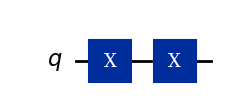

<IPython.core.display.Latex object>

probabilities = {'0': 1.0}
  vector       = [1.+0.j 0.+0.j]
  back to |0>? True

Gate Y applied twice


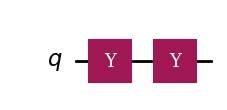

<IPython.core.display.Latex object>

probabilities = {'0': 1.0}
  vector       = [1.+0.j 0.+0.j]
  back to |0>? True

Gate Z applied twice


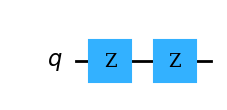

<IPython.core.display.Latex object>

probabilities = {'0': 1.0}
  vector       = [1.+0.j 0.+0.j]
  back to |0>? True

Gate H applied twice


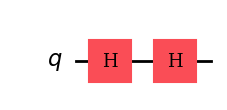

<IPython.core.display.Latex object>

probabilities = {'0': 1.0}
  vector       = [1.+0.j 0.+0.j]
  back to |0>? True



In [20]:
twiceGates = ["x", "y", "z", "h"]
twiceResults = {}

for name in twiceGates:
    qc = QuantumCircuit(1)
    getattr(qc, name)(0)  # first time
    getattr(qc, name)(0)  # second time

    print(f"Gate {name.upper()} applied twice")
    state, probs = analyzeCircuit(qc)
    twiceResults[name.upper()] = state
    print(f"  vector       = {state.data}")
    print(f"  back to |0>? {np.allclose(state.data, ket0)}")
    print()

Completa la tabla:

| Puerta aplicada dos veces | Estado final |
|---|---|
| X | \|0⟩ |
| Y | \|0⟩ |
| Z | \|0⟩ |
| H | \|0⟩ |

**Responde:**

1. ¿Qué tienen en común estas puertas?
2. ¿Qué significa que una puerta sea su propia inversa?
3. ¿Se cumple exactamente o aparece alguna fase global en algún caso?

**Respuesta:**

1. Que al aplicarlas dos veces se vuelve al estado inicial: las cuatro dan `back to |0>? True`. Son a la vez unitarias y hermíticas (U = U†).

2. Que U² = I, es decir U⁻¹ = U. Para deshacerla basta con aplicarla otra vez.

3. Se cumple exactamente, el vector final es (1, 0) sin ningún factor. Incluso con Y, que mete fases i y −i, se cancelan: Y·Y = I. Si se usara iY en vez de Y sí aparecería una fase global −1, porque (iY)² = −I.

### Ejercicio 18. Inversas de S y T

Crea los siguientes circuitos:

```python
qc_s = QuantumCircuit(1)
qc_s.h(0)
qc_s.s(0)
qc_s.sdg(0)
```

```python
qc_t = QuantumCircuit(1)
qc_t.h(0)
qc_t.t(0)
qc_t.tdg(0)
```

S followed by Sdg


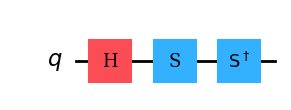

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}
  back to |+>? True

T followed by Tdg


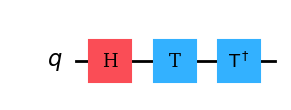

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}
  back to |+>? True

Sdg is S†? True
Tdg is T†? True


In [21]:
qcSInv = QuantumCircuit(1)
qcSInv.h(0)
qcSInv.s(0)
qcSInv.sdg(0)

qcTInv = QuantumCircuit(1)
qcTInv.h(0)
qcTInv.t(0)
qcTInv.tdg(0)

print("S followed by Sdg")
stateSInv, probsSInv = analyzeCircuit(qcSInv)
print(f"  back to |+>? {np.allclose(stateSInv.data, ketPlus)}")
print()

print("T followed by Tdg")
stateTInv, probsTInv = analyzeCircuit(qcTInv)
print(f"  back to |+>? {np.allclose(stateTInv.data, ketPlus)}")
print()

print(f"Sdg is S†? {np.allclose(S.conj().T @ S, I)}")
print(f"Tdg is T†? {np.allclose(T.conj().T @ T, I)}")

**Responde:**

1. ¿Qué hace `sdg`?
2. ¿Qué hace `tdg`?
3. ¿Por qué el estado final vuelve a coincidir con el estado anterior a aplicar `s` o `t`?
4. ¿Qué relación tiene esto con la reversibilidad?

**Respuesta:**

1. Es S† (S daga), la inversa de S. Multiplica la amplitud de |1⟩ por −i, es decir, resta la fase de π/2.

2. Es T†, la inversa de T. Multiplica la amplitud de |1⟩ por e^(−iπ/4).

3. Porque S†S = I y T†T = I (se comprueba al final de la celda). La fase que añade `s` o `t` la quita `sdg` o `tdg`, y los dos circuitos vuelven a |+⟩ (`back to |+>? True`).

4. Toda puerta unitaria es reversible y su inversa es U†. Aquí se ve directamente: después de aplicar U y U† el estado queda igual que antes.

## 9. Parte H. Rotaciones

### Ejercicio 19. Rotación $R_y(\theta)$

Crea circuitos que apliquen $R_y(\theta)$ sobre $|0\rangle$ para los siguientes valores:

$$
\theta = 0,\ \frac{\pi}{4},\ \frac{\pi}{2},\ \pi
$$

theta = 0.0000 (0.00π)


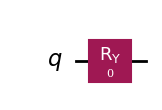

<IPython.core.display.Latex object>

probabilities = {'0': 1.0}

theta = 0.7854 (0.25π)


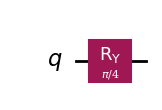

<IPython.core.display.Latex object>

probabilities = {'0': 0.85355, '1': 0.14645}

theta = 1.5708 (0.50π)


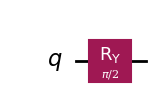

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}

theta = 3.1416 (1.00π)


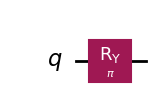

<IPython.core.display.Latex object>

probabilities = {'0': 0.0, '1': 1.0}

 theta |  amp |0>  amp |1> |   P(0)   P(1) | cos²(θ/2)
------------------------------------------------------------
 0.00π |   1.0000   0.0000 | 1.0000 0.0000 |    1.0000
 0.25π |   0.9239   0.3827 | 0.8536 0.1464 |    0.8536
 0.50π |   0.7071   0.7071 | 0.5000 0.5000 |    0.5000
 1.00π |   0.0000   1.0000 | 0.0000 1.0000 |    0.0000


In [22]:
angles = [0, np.pi / 4, np.pi / 2, np.pi]
ryResults = []

for theta in angles:
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)

    state = Statevector.from_instruction(qc)
    probs = probsDict(state)

    ryResults.append((theta, state, probs))

    print(f"theta = {theta:.4f} ({theta / np.pi:.2f}π)")
    display(qc.draw("mpl"))
    display(state.draw("latex"))
    print(f"probabilities = {probs}")
    print()

print(f"{'theta':>6} | {'amp |0>':>8} {'amp |1>':>8} | {'P(0)':>6} {'P(1)':>6} | {'cos²(θ/2)':>9}")
print("-" * 60)
for theta, state, _ in ryResults:
    p0, p1 = state.probabilities()
    print(f"{theta / np.pi:>5.2f}π | {state.data[0].real:>8.4f} {state.data[1].real:>8.4f} | "
          f"{p0:>6.4f} {p1:>6.4f} | {np.cos(theta / 2) ** 2:>9.4f}")

Completa la tabla:

| $\theta$ | Estado aproximado | P(0) | P(1) |
|---:|---|---:|---:|
| 0 | \|0⟩ | 1 | 0 |
| $\pi/4$ | 0.924\|0⟩ + 0.383\|1⟩ | 0.854 | 0.146 |
| $\pi/2$ | 0.707\|0⟩ + 0.707\|1⟩ = \|+⟩ | 0.5 | 0.5 |
| $\pi$ | \|1⟩ | 0 | 1 |

**Responde:**

1. ¿Qué ocurre cuando aumenta $\theta$?
2. ¿Qué valor de $\theta$ produce una superposición equilibrada?
3. ¿Qué valor de $\theta$ lleva aproximadamente de $|0\rangle$ a $|1\rangle$?
4. ¿Por qué las rotaciones son útiles?

**Respuesta:**

1. La probabilidad pasa poco a poco de |0⟩ a |1⟩. El estado es cos(θ/2)|0⟩ + sin(θ/2)|1⟩, así que P(0) = cos²(θ/2), que coincide con la última columna de la tabla.

2. θ = π/2, que da |+⟩ con 0.5 y 0.5.

3. θ = π, que da |1⟩. Exacto salvo por un error de redondeo del orden de 10⁻¹⁷ en la amplitud de |0⟩.

4. Porque permiten ajustar las amplitudes de forma continua, no solo a los valores fijos de X o H. Con Ry se puede preparar cualquier reparto de probabilidades, y como dependen de un parámetro θ se usan en algoritmos variacionales donde el ángulo se optimiza.

### Ejercicio 20. Rotación $R_z(\theta)$)

Crea circuitos que preparen primero $|+\rangle$ y después apliquen $R_z(\theta)$:

```python
qc = QuantumCircuit(1)
qc.h(0)
qc.rz(theta, 0)
```

Utiliza:

$$
\theta = 0,\ \frac{\pi}{2},\ \pi
$$

theta = 0.0000 (0.00π)


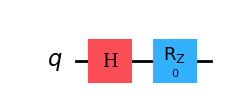

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}

theta = 1.5708 (0.50π)


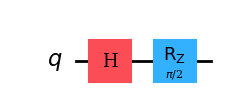

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}

theta = 3.1416 (1.00π)


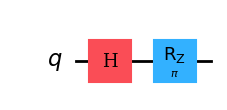

<IPython.core.display.Latex object>

probabilities = {'0': 0.5, '1': 0.5}

 theta | vector                           |  P(0)  P(1) | relative phase
----------------------------------------------------------------------
 0.00π | [0.7071+0.j 0.7071+0.j]          |  0.50  0.50 | 0.00π
 0.50π | [0.5-0.5j 0.5+0.5j]              |  0.50  0.50 | 0.50π
 1.00π | [0.-0.7071j 0.+0.7071j]          |  0.50  0.50 | 1.00π


In [23]:
rzAngles = [0, np.pi / 2, np.pi]
rzResults = []

for theta in rzAngles:
    qc = QuantumCircuit(1)
    qc.h(0)  # |+>
    qc.rz(theta, 0)

    state = Statevector.from_instruction(qc)
    probs = probsDict(state)

    rzResults.append((theta, state, probs))

    print(f"theta = {theta:.4f} ({theta / np.pi:.2f}π)")
    display(qc.draw("mpl"))
    display(state.draw("latex"))
    print(f"probabilities = {probs}")
    print()

print(f"{'theta':>6} | {'vector':<32} | {'P(0)':>5} {'P(1)':>5} | relative phase")
print("-" * 70)
for theta, state, _ in rzResults:
    p0, p1 = state.probabilities()
    relativePhase = np.angle(state.data[1] / state.data[0])  # phase of |1> relative to |0>
    print(f"{theta / np.pi:>5.2f}π | {str(np.round(state.data, 4)):<32} | {p0:>5.2f} {p1:>5.2f} | {relativePhase / np.pi:.2f}π")

**Responde:**

1. ¿Cambian las probabilidades?
2. ¿Cambia el estado?
3. ¿Qué modifica principalmente $R_z$?
4. ¿Por qué este efecto puede no verse en un histograma de la base computacional?

**Respuesta:**

1. No, con los tres ángulos sale 0.5 y 0.5.

2. Sí. Los vectores son distintos, y la fase relativa de |1⟩ sale 0, π/2 y π, la misma que el ángulo θ.

3. La fase relativa entre |0⟩ y |1⟩, es un giro alrededor del eje Z. Además Rz(θ) mete una fase global e^(−iθ/2), por eso con θ = π el vector sale (−i/√2, i/√2) en vez de (1/√2, −1/√2). Quitando esa fase global es |−⟩.

4. Porque el histograma solo ve |α|² y |β|², y Rz solo cambia fases, no módulos. Para verlo habría que aplicar una H antes de medir, como en el ejercicio 14.

## 10. Parte I. Medidas y conteos

### Ejercicio 21. Medir después de aplicar puertas

Crea un circuito que prepare el estado:

$$
|+\rangle =
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

y lo mida con `shots = 1000`.

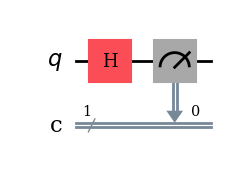

counts       = {'1': 486, '0': 514}
frequencies  = {'1': 0.486, '0': 0.514}
|f(0) - 0.5| = 0.0140   (sigma_f = 0.0158)


In [24]:
shots = 1000

qcMeasure = QuantumCircuit(1, 1)
qcMeasure.h(0)  # |+>
qcMeasure.measure(0, 0)

display(qcMeasure.draw("mpl"))

simulator = AerSimulator(seed_simulator=SEED)
qcTranspiled = transpile(qcMeasure, simulator)

result = simulator.run(qcTranspiled, shots=shots).result()
counts = result.get_counts()

freqs = {k: v / shots for k, v in counts.items()}
sigma = np.sqrt(0.5 * 0.5 / shots)

print(f"counts       = {counts}")
print(f"frequencies  = {freqs}")
print(f"|f(0) - 0.5| = {abs(freqs.get('0', 0) - 0.5):.4f}   (sigma_f = {sigma:.4f})")

**Responde:**

1. ¿Qué resultados esperas obtener?
2. ¿Coinciden exactamente con 500 y 500?
3. ¿Por qué?
4. ¿Qué diferencia hay entre probabilidades teóricas y conteos?

**Respuesta:**

1. Alrededor de 500 veces 0 y 500 veces 1, porque |+⟩ tiene P(0) = P(1) = 0.5.

2. No, salen 514 y 486.

3. Porque cada shot es aleatorio. La desviación esperada es σ_f = √(0.5·0.5/1000) ≈ 0.016, y aquí |f(0) − 0.5| = 0.014, dentro de lo normal.

4. Las probabilidades son valores exactos que salen de las amplitudes. Los conteos son el resultado de repetir el experimento un número finito de veces, así que solo estiman las probabilidades y se acercan más cuantos más shots hay.

### Ejercicio 22. Histograma de resultados

Representa los conteos del ejercicio anterior mediante un gráfico de barras.

El gráfico debe incluir:

- Título.
- Etiqueta del eje X.
- Etiqueta del eje Y.
- Valores encima de las barras.

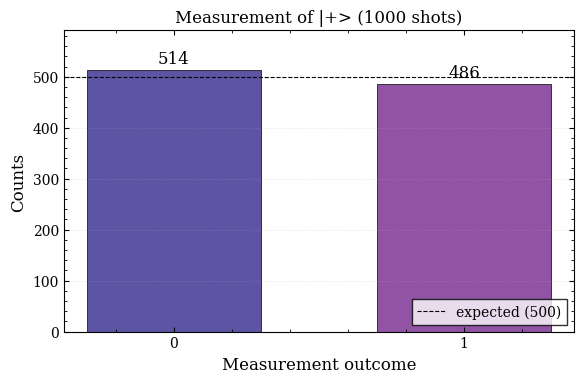

In [25]:
labels = sorted(counts)
values = [counts[k] for k in labels]

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(labels, values, color=[COLOR_TARGET, COLOR_PRED], width=0.6, edgecolor="black", linewidth=0.5)
ax.axhline(shots / 2, color="black", linestyle="--", linewidth=0.8, label=f"expected ({shots // 2})")

for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 5, str(value), ha="center", va="bottom")

ax.set_xlabel("Measurement outcome")
ax.set_ylabel("Counts")
ax.set_title(f"Measurement of |+> ({shots} shots)")
ax.set_ylim(0, max(values) * 1.15)
ax.legend(loc="lower right")
ax.grid(True, axis="y", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

**Responde:**

1. ¿Qué representa el histograma?
2. ¿Muestra directamente las amplitudes?
3. ¿Muestra directamente la fase?
4. ¿Qué información se pierde al medir?

**Respuesta:**

1. Cuántas veces salió cada resultado en los 1000 shots, 514 veces 0 y 486 veces 1. La línea discontinua marca los 500 esperados.

2. No. Solo muestra conteos, que estiman |α|² y |β|², no α y β.

3. No. |+⟩ y |−⟩ darían el mismo histograma aunque tienen distinta fase relativa.

4. La fase y en general las amplitudes. La medida colapsa el estado a |0⟩ o |1⟩, así que después ya no queda la superposición y solo tenemos un bit por shot.

## 11. Reto avanzado

### Ejercicio 23. Distinguir $|+\rangle$ y $|-\rangle$ mediante una operación previa

Sabemos que $|+\rangle$ y $|-\rangle$ producen las mismas probabilidades si se miden directamente en la base computacional.

Diseña un procedimiento con Qiskit para distinguirlos.

Pista: antes de medir, aplica una puerta adecuada.

Debes construir dos circuitos:

1. Uno que prepare $|+\rangle$, aplique la operación elegida y mida.
2. Otro que prepare $|-\rangle$, aplique la operación elegida y mida.

Ejecuta ambos con `shots=1000`.

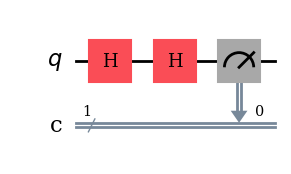

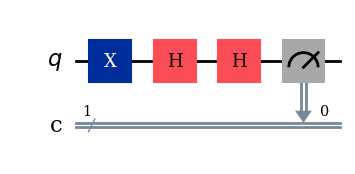

counts for |+> = {'0': 1000}
counts for |-> = {'1': 1000}

direct measurement of |+> = {'1': 486, '0': 514}
direct measurement of |-> = {'1': 486, '0': 514}


In [26]:
qcPlusMeasure = QuantumCircuit(1, 1)
qcPlusMeasure.h(0)  # prepares |+>
qcPlusMeasure.h(0)  # operation before measuring
qcPlusMeasure.measure(0, 0)

qcMinusMeasure = QuantumCircuit(1, 1)
qcMinusMeasure.x(0)
qcMinusMeasure.h(0)  # prepares |->
qcMinusMeasure.h(0)  # operation before measuring
qcMinusMeasure.measure(0, 0)

display(qcPlusMeasure.draw("mpl"))
display(qcMinusMeasure.draw("mpl"))

simulator = AerSimulator(seed_simulator=SEED)

qcPlusTranspiled = transpile(qcPlusMeasure, simulator)
qcMinusTranspiled = transpile(qcMinusMeasure, simulator)

countsPlus = simulator.run(qcPlusTranspiled, shots=shots).result().get_counts()
countsMinus = simulator.run(qcMinusTranspiled, shots=shots).result().get_counts()

print(f"counts for |+> = {countsPlus}")
print(f"counts for |-> = {countsMinus}")
print()

# without the extra H both states give ~50/50
for name, prep in [("|+>", ["h"]), ("|->", ["x", "h"])]:
    qc = QuantumCircuit(1, 1)
    for gate in prep:
        getattr(qc, gate)(0)
    qc.measure(0, 0)
    directCounts = simulator.run(transpile(qc, simulator), shots=shots).result().get_counts()
    print(f"direct measurement of {name} = {directCounts}")

Completa la tabla:

| Estado inicial | Operación antes de medir | Resultado esperado | Conteos obtenidos |
|---|---|---|---|
| $\|+\rangle$ | H | Siempre 0 (H\|+⟩ = \|0⟩) | {'0': 1000} |
| $\|-\rangle$ | H | Siempre 1 (H\|−⟩ = \|1⟩) | {'1': 1000} |

**Responde:**

1. ¿Qué puerta has utilizado antes de medir?
2. ¿Por qué permite distinguir los dos estados?
3. ¿Qué resultado se obtiene para $|+\rangle$?
4. ¿Qué resultado se obtiene para $|-\rangle$?
5. ¿Qué demuestra este experimento sobre la fase relativa?

**Respuesta:**

1. Una H.

2. Porque H convierte la base {|+⟩, |−⟩} en la base computacional: H|+⟩ = |0⟩ y H|−⟩ = |1⟩. Es como medir en la base X en vez de en la Z, y así la diferencia de signo se convierte en un resultado distinto.

3. Siempre 0, `{'0': 1000}`.

4. Siempre 1, `{'1': 1000}`.

5. Que la fase relativa es información física real, aunque no se vea en una medida directa. Al final de la celda se ve que sin la H los dos dan `{'1': 486, '0': 514}` (los mismos conteos porque tienen las mismas probabilidades y uso la misma semilla), y con la H se distinguen en el 100 % de los shots.

## 12. Pruebas mínimas

Incluye al final del notebook las siguientes pruebas mediante `assert`.

Las pruebas deben ejecutarse sin errores cuando la práctica esté completada correctamente.

In [27]:
assert np.isclose(np.linalg.norm(ket0), 1)
assert np.isclose(np.linalg.norm(ket1), 1)

assert isUnitary(I)
assert isUnitary(X)
assert isUnitary(Y)
assert isUnitary(Z)
assert isUnitary(H)
assert isUnitary(S)
assert isUnitary(T)

assert np.allclose(X @ ket0, ket1)
assert np.allclose(H @ ket0, ketPlus)
assert np.allclose(H @ H, I)

for state in [ket0, ket1, ketPlus, ketMinus]:
    probs = computeProbabilities(state)
    assert np.isclose(sum(probs.values()), 1)

assert sum(counts.values()) == shots

assert not isUnitary(np.ones((2, 3)))                   # not square
assert not isUnitary(2 * X)                             # U†U != I
assert np.allclose(T @ T, S)                            # T² = S
assert not np.allclose(Z @ H, H @ Z)                    # Z and H do not commute
assert np.allclose(Z @ ket1, -ket1)                     # Z|1> = -|1>
assert probsAFinal == {"0": 1.0}                        # H|+> = |0>
assert probsBFinal == {"1": 1.0}                        # H|-> = |1>
assert countsPlus == {"0": shots}                       # |+> always 0 after H
assert countsMinus == {"1": shots}                      # |-> always 1 after H

print("All tests passed")

All tests passed


## 13. Conclusión final

Redacta una conclusión de entre 150 y 250 palabras respondiendo a estas preguntas:

1. ¿Qué es una puerta cuántica de un qubit?
2. ¿Por qué las puertas cuánticas deben ser unitarias?
3. ¿Qué diferencia hay entre una puerta que cambia probabilidades y una puerta que cambia fase?
4. ¿Por qué dos estados distintos pueden producir el mismo histograma?
5. ¿Por qué el orden de las puertas importa?
6. ¿Qué has comprobado al comparar NumPy y Qiskit?

**Conclusión:**

1. Una puerta de un qubit es una matriz 2 × 2 unitaria que transforma el vector de estado. Aplicarla es multiplicar la matriz por el vector.

2. Porque tienen que conservar la norma, para que las probabilidades sigan sumando 1, y tienen que ser reversibles. Toda puerta unitaria tiene inversa U†, como S y `sdg` o T y `tdg`.

3. Puertas como X, Y, H o Ry cambian los módulos de las amplitudes y por tanto las probabilidades. Z, S, T o Rz solo cambian la fase relativa de |1⟩, así que el estado cambia pero las probabilidades en la base computacional no.

4. Porque la medida en la base computacional solo ve |α|² y |β|². Estados como |+⟩ y |−⟩ tienen las mismas probabilidades y solo se diferencian en la fase relativa. Para distinguirlos hay que aplicar una puerta antes de medir, como la H del reto.

5. Porque las matrices en general no conmutan. HZ|0⟩ da |+⟩ y ZH|0⟩ da |−⟩, así que las mismas puertas en distinto orden dan estados distintos.

6. Que dan exactamente los mismos estados en todos los casos. Un circuito de Qiskit es otra forma de escribir productos de matrices, con la diferencia de que el circuito se lee de izquierda a derecha y el producto de derecha a izquierda.